In [2]:
# Librerías
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Raíz del proyecto
PROJECT_ROOT = Path().resolve().parents[1]
# Rutas de entrada
path_eva07 = PROJECT_ROOT / "data" / "raw" / "EVA_20072018.csv"
print("eva:", path_eva07)

eva: /home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/raw/EVA_20072018.csv


In [4]:
# Cargar base
eva_before = pd.read_csv(path_eva07, encoding="utf-8-sig")
print("Base eva:", eva_before.shape)
eva_before.head(5)

Base eva: (206068, 17)


/tmp/ipykernel_85087/1008549273.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  eva_before = pd.read_csv(path_eva07, encoding="utf-8-sig")


,CÓD. \nDEP.,DEPARTAMENTO,CÓD. MUN.,MUNICIPIO,GRUPO \nDE CULTIVO,SUBGRUPO \nDE CULTIVO,CULTIVO,DESAGREGACIÓN REGIONAL Y/O SISTEMA PRODUCTIVO,AÑO,PERIODO,Área Sembrada\n(ha),Área Cosechada\n(ha),Producción\n(t),Rendimiento\n(t/ha),ESTADO FISICO PRODUCCION,NOMBRE \nCIENTIFICO,CICLO DE CULTIVO
0,15,BOYACA,15.114,BUSBANZA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2.006,2006B,2.0,1.0,1.0,1,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
1,25,CUNDINAMARCA,25.754,SOACHA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2.006,2006B,82.0,80.0,1.44,18,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
2,25,CUNDINAMARCA,25.214,COTA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2.006,2006B,2.0,2.0,26.0,"17,33",FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
3,54,NORTE DE SANTANDER,54.405,LOS PATIOS,HORTALIZAS,ACELGA,ACELGA,ACELGA,2.006,2006B,3.0,3.0,48.0,16,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
4,54,NORTE DE SANTANDER,54.518,PAMPLONA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2.006,2006B,1.0,1.0,5.0,10,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO


In [5]:
# eva_before.info()

In [6]:
eva_before.columns

Index(['CÓD. \nDEP.', 'DEPARTAMENTO', 'CÓD. MUN.', 'MUNICIPIO',
       'GRUPO \nDE CULTIVO', 'SUBGRUPO \nDE CULTIVO', 'CULTIVO',
       'DESAGREGACIÓN REGIONAL Y/O SISTEMA PRODUCTIVO', 'AÑO', 'PERIODO',
       'Área Sembrada\n(ha)', 'Área Cosechada\n(ha)', 'Producción\n(t)',
       'Rendimiento\n(t/ha)', 'ESTADO FISICO PRODUCCION',
       'NOMBRE \nCIENTIFICO', 'CICLO DE CULTIVO'],
      dtype='object')

In [7]:
cafe_caldas_before = eva_before[
    (eva_before['DEPARTAMENTO'] == 'CALDAS') &
    (eva_before['CULTIVO'] == 'CAFE')
    ].copy()
cafe_caldas_before.head()

,CÓD. \nDEP.,DEPARTAMENTO,CÓD. MUN.,MUNICIPIO,GRUPO \nDE CULTIVO,SUBGRUPO \nDE CULTIVO,CULTIVO,DESAGREGACIÓN REGIONAL Y/O SISTEMA PRODUCTIVO,AÑO,PERIODO,Área Sembrada\n(ha),Área Cosechada\n(ha),Producción\n(t),Rendimiento\n(t/ha),ESTADO FISICO PRODUCCION,NOMBRE \nCIENTIFICO,CICLO DE CULTIVO
38176,17,CALDAS,17.001,MANIZALES,OTROS PERMANENTES,CAFE,CAFE,CAFE,2.007,2007,9.268,6.424,10.848,"1,69",CAFE VERDE EQUIVALENTE,COFFEA ARABICA,PERMANENTE
38177,17,CALDAS,17.042,ANSERMA,OTROS PERMANENTES,CAFE,CAFE,CAFE,2.007,2007,7.125,5.485,7.131,"1,3",CAFE VERDE EQUIVALENTE,COFFEA ARABICA,PERMANENTE
38178,17,CALDAS,17.541,PENSILVANIA,OTROS PERMANENTES,CAFE,CAFE,CAFE,2.007,2007,5.931,5.900,5.908,1,CAFE VERDE EQUIVALENTE,COFFEA ARABICA,PERMANENTE
38179,17,CALDAS,17.174,CHINCHINA,OTROS PERMANENTES,CAFE,CAFE,CAFE,2.007,2007,5.632,5.631,9.203,"1,63",CAFE VERDE EQUIVALENTE,COFFEA ARABICA,PERMANENTE
38180,17,CALDAS,17.524,PALESTINA,OTROS PERMANENTES,CAFE,CAFE,CAFE,2.007,2007,4.777,4.400,6.160,"1,4",CAFE VERDE EQUIVALENTE,COFFEA ARABICA,PERMANENTE


In [8]:
cafe_caldas_before.drop(columns=['CÓD. \nDEP.','DEPARTAMENTO','GRUPO \nDE CULTIVO', 'SUBGRUPO \nDE CULTIVO',
                          'CULTIVO', 'DESAGREGACIÓN REGIONAL Y/O SISTEMA PRODUCTIVO', 'AÑO', 'ESTADO FISICO PRODUCCION','NOMBRE \nCIENTIFICO', 
                          'CICLO DE CULTIVO'], inplace=True)
cafe_caldas_before.head()

,CÓD. MUN.,MUNICIPIO,PERIODO,Área Sembrada\n(ha),Área Cosechada\n(ha),Producción\n(t),Rendimiento\n(t/ha)
38176,17.001,MANIZALES,2007,9.268,6.424,10.848,"1,69"
38177,17.042,ANSERMA,2007,7.125,5.485,7.131,"1,3"
38178,17.541,PENSILVANIA,2007,5.931,5.900,5.908,1
38179,17.174,CHINCHINA,2007,5.632,5.631,9.203,"1,63"
38180,17.524,PALESTINA,2007,4.777,4.400,6.160,"1,4"


In [9]:
# Ajuste de datos por configuración regional
cafe_caldas_before["CÓD. MUN."] = (
    cafe_caldas_before["CÓD. MUN."]
    .astype(str)
    .str.replace(".", "", regex=False)
)
cafe_caldas_before["CÓD. MUN."] = cafe_caldas_before["CÓD. MUN."].str.zfill(5)

# Eliminación de separador de miles
cols_numeric = [
    'Área Sembrada\n(ha)',
    'Área Cosechada\n(ha)',
    'Producción\n(t)',
    'Rendimiento\n(t/ha)'
]

for col in cols_numeric:
    cafe_caldas_before[col] = cafe_caldas_before[col].astype(str).str.replace(".", "", regex=False)

# Sustitución de separador decimal
for col in cols_numeric:
    cafe_caldas_before[col] = cafe_caldas_before[col].str.replace(",", ".", regex=False)

# Tipificación
for col in cols_numeric:
    cafe_caldas_before[col] = pd.to_numeric(cafe_caldas_before[col], errors='coerce')

cafe_caldas_before.head()

,CÓD. MUN.,MUNICIPIO,PERIODO,Área Sembrada\n(ha),Área Cosechada\n(ha),Producción\n(t),Rendimiento\n(t/ha)
38176,17001,MANIZALES,2007,9268,6424,10848,1.69
38177,17042,ANSERMA,2007,7125,5485,7131,1.30
38178,17541,PENSILVANIA,2007,5931,59,5908,1.00
38179,17174,CHINCHINA,2007,5632,5631,9203,1.63
38180,17524,PALESTINA,2007,4777,44,6160,1.40


In [10]:
cafe_caldas_before.columns

Index(['CÓD. MUN.', 'MUNICIPIO', 'PERIODO', 'Área Sembrada\n(ha)',
       'Área Cosechada\n(ha)', 'Producción\n(t)', 'Rendimiento\n(t/ha)'],
      dtype='object')

In [11]:
cafe_caldas_before.rename(columns={
    'CÓD. MUN.': 'Código Dane municipio',
    'MUNICIPIO': 'Municipio',
    'PERIODO': 'Año',
    'Área Sembrada\n(ha)': 'Área sembrada (ha)',
    'Área Cosechada\n(ha)': 'Área cosechada (ha)',
    'Producción\n(t)': 'Producción (t)',
    'Rendimiento\n(t/ha)': 'Rendimiento (t/ha)'
}, inplace=True)
print(cafe_caldas_before.columns.tolist())

['Código Dane municipio', 'Municipio', 'Año', 'Área sembrada (ha)', 'Área cosechada (ha)', 'Producción (t)', 'Rendimiento (t/ha)']


In [12]:
cafe_caldas_before.head()

,Código Dane municipio,Municipio,Año,Área sembrada (ha),Área cosechada (ha),Producción (t),Rendimiento (t/ha)
38176,17001,MANIZALES,2007,9268,6424,10848,1.69
38177,17042,ANSERMA,2007,7125,5485,7131,1.30
38178,17541,PENSILVANIA,2007,5931,59,5908,1.00
38179,17174,CHINCHINA,2007,5632,5631,9203,1.63
38180,17524,PALESTINA,2007,4777,44,6160,1.40


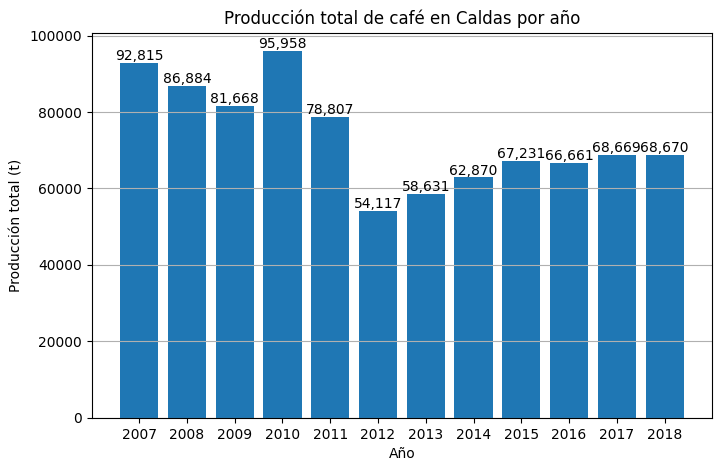

In [13]:
# Producción total departamental por año
produccion_caldas = cafe_caldas_before.groupby(['Año'])['Producción (t)'].sum().reset_index()

plt.figure(figsize=(8, 5))

bars = plt.bar(produccion_caldas['Año'], produccion_caldas['Producción (t)'])

# Etiquetas sobre cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,   # posición horizontal (centro de la barra)
        height,                              # altura (valor)
        f'{height:,.0f}',                    # formato del número
        ha='center',                         # alineación horizontal
        va='bottom'                          # alineación vertical
    )

plt.xlabel('Año')
plt.ylabel('Producción total (t)')
plt.title('Producción total de café en Caldas por año')

plt.grid(axis='y')

plt.show()

In [14]:
print("Municipios en los que se siembra café en Caldas: ")
print(cafe_caldas_before['Municipio'].unique())
print("\nPeriodos de tiempo disponibles: ")
print("" + str(cafe_caldas_before['Año'].unique()))

Municipios en los que se siembra café en Caldas: 
['MANIZALES' 'ANSERMA' 'PENSILVANIA' 'CHINCHINA' 'PALESTINA' 'SAMANA'
 'AGUADAS' 'MARQUETALIA' 'NEIRA' 'PACORA' 'MANZANARES' 'RIOSUCIO'
 'RISARALDA' 'BELALCAZAR' 'SALAMINA' 'FILADELFIA' 'ARANZAZU' 'SAN JOSE'
 'SUPIA' 'VILLAMARIA' 'LA MERCED' 'MARMATO' 'VITERBO' 'VICTORIA'
 'MARULANDA']

Periodos de tiempo disponibles: 
['2007' '2008' '2009' '2010' '2011' '2012' '2013' '2014' '2015' '2016'
 '2017' '2018']


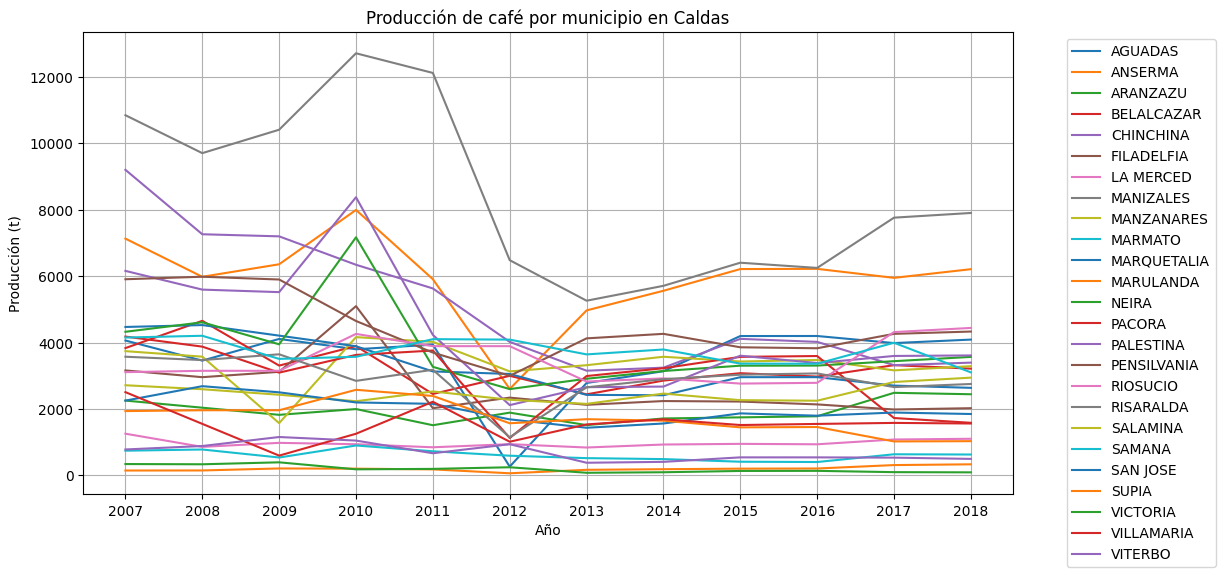

In [15]:
produccion_municipio = cafe_caldas_before.groupby(['Municipio', 'Año'])['Producción (t)'].sum().reset_index()
tabla_grafica_mun = produccion_municipio.pivot(index='Año', columns='Municipio', values='Producción (t)')

plt.figure(figsize=(12, 6))

for municipio in tabla_grafica_mun.columns:
    plt.plot(tabla_grafica_mun.index, tabla_grafica_mun[municipio], label=municipio)

plt.xlabel('Año')
plt.ylabel('Producción (t)')
plt.title('Producción de café por municipio en Caldas')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.show()

In [17]:
PROJECT_ROOT = Path().resolve().parents[1]
output_path = PROJECT_ROOT / "data" / "middle" / "produccion_caldas_municipal_2007-2018.csv"
print(output_path)
cafe_caldas_before.to_csv(output_path, index=False, encoding='utf-8-sig')

/home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/middle/produccion_caldas_municipal_2007-2018.csv


In [18]:
# Raíz del proyecto
PROJECT_ROOT = Path().resolve().parents[1]
# Rutas de entrada
path_after = PROJECT_ROOT / "data" / "middle" / "produccion_caldas_municipal_2019-2024.csv"
print("Producción 2019 - 2024:", path_after)

Producción 2019 - 2024: /home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/middle/produccion_caldas_municipal_2019-2024.csv


In [19]:
cafe_caldas_after = pd.read_csv(path_after, encoding="utf-8-sig")
print("Base eva reciente:", cafe_caldas_after.shape)
cafe_caldas_after.head(5)

Base eva reciente: (150, 7)


,Código Dane municipio,Municipio,Año,Área sembrada (ha),Área cosechada (ha),Producción (t),Rendimiento (t/ha)
0,17001,Manizales,2019,5075.00,3444.00,4597.00,1.33
1,17001,Manizales,2020,4920.00,3362.00,4149.00,1.23
2,17001,Manizales,2021,4781.70,3268.13,4934.88,1.51
3,17001,Manizales,2022,4765.43,3386.54,4076.85,1.20
4,17001,Manizales,2023,4778.52,3466.14,6275.13,1.81


In [43]:
cafe_caldas_after["Municipio"] = (
    cafe_caldas_after["Municipio"]
    .str.strip()
    .str.upper()
)

In [50]:
# Unificación de nombres de municipios
mapa_nombres = {
    "BELALCAZAR": "BELALCÁZAR",
    "CHINCHINA": "CHINCHINÁ",
    "PACORA": "PÁCORA",
    "SAMANA": "SAMANÁ",
    "SAN JOSE": "SAN JOSÉ",
    "SUPIA": "SUPÍA",
    "VILLAMARIA": "VILLAMARÍA"
}

cafe_caldas_before["Municipio"] = cafe_caldas_before["Municipio"].replace(mapa_nombres)

In [51]:
cafe_caldas_before["Año"] = pd.to_numeric(cafe_caldas_before["Año"], errors="coerce").astype(int)

In [52]:
print(cafe_caldas_before.columns.tolist())
print(cafe_caldas_after.columns.tolist())

['Código Dane municipio', 'Municipio', 'Año', 'Área sembrada (ha)', 'Área cosechada (ha)', 'Producción (t)', 'Rendimiento (t/ha)']
['Código Dane municipio', 'Municipio', 'Año', 'Área sembrada (ha)', 'Área cosechada (ha)', 'Producción (t)', 'Rendimiento (t/ha)']


In [53]:
cafe_caldas = pd.concat(
    [cafe_caldas_before, cafe_caldas_after],
    ignore_index=True
)

In [54]:
# Concatenación de bases y ordenamiento
cafe_caldas = cafe_caldas.sort_values(
    ["Código Dane municipio", "Año"]
).reset_index(drop=True)

In [55]:
# Validaciones de calidad de los datos
print("Cobertura temporal de la base de datos:")
print(sorted(cafe_caldas["Año"].unique()))
print("\nCobertura territorial de la base de datos:")
print(cafe_caldas["Municipio"].nunique())
print("\nDimensión final de la base de datos (municipios x años):")
print(cafe_caldas.shape)

Cobertura temporal de la base de datos:
[2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Cobertura territorial de la base de datos:
25

Dimensión final de la base de datos (municipios x años):
(450, 7)


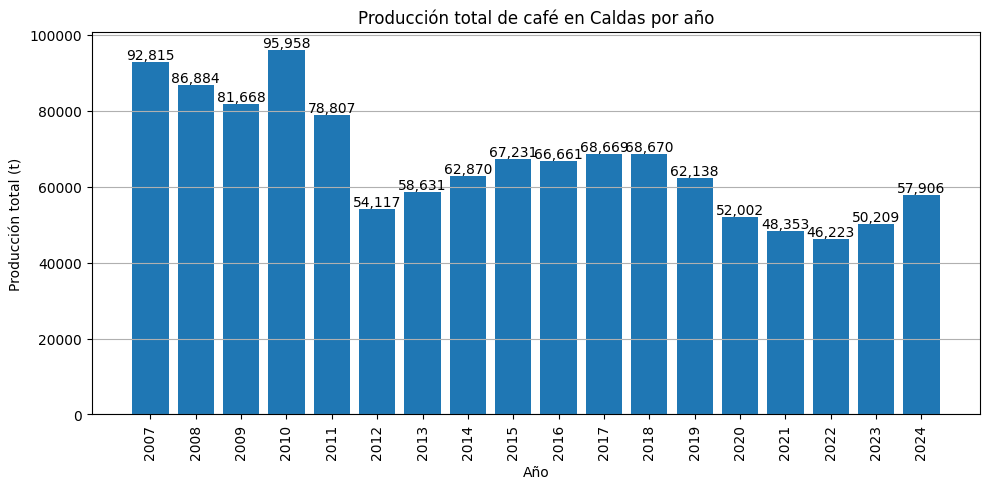

In [58]:
# Producción total departamental al año
produccion_caldas = cafe_caldas.groupby(['Año'])['Producción (t)'].sum().reset_index()

plt.figure(figsize=(10, 5))

bars = plt.bar(produccion_caldas['Año'], produccion_caldas['Producción (t)'])

# Etiquetas sobre cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom'
    )

plt.xticks(produccion_caldas['Año'], rotation=90)
plt.xlabel('Año')
plt.ylabel('Producción total (t)')
plt.title('Producción total de café en Caldas por año')
plt.grid(axis='y')
plt.tight_layout()

plt.show()

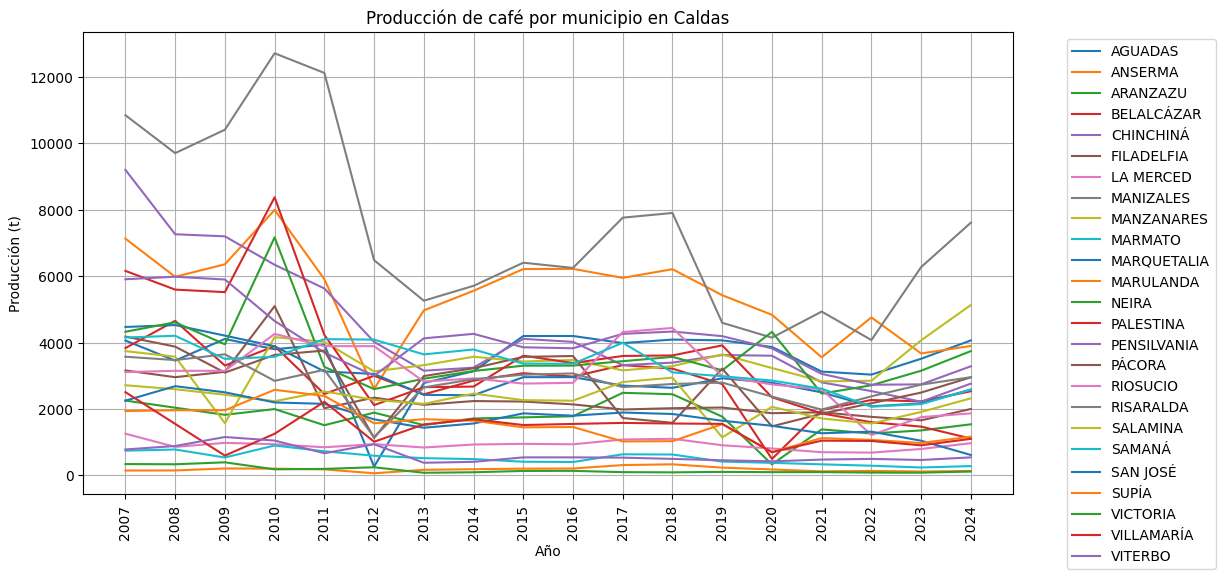

In [62]:
produccion_municipio = cafe_caldas.groupby(['Municipio', 'Año'])['Producción (t)'].sum().reset_index()
tabla_grafica_mun = produccion_municipio.pivot(index='Año', columns='Municipio', values='Producción (t)')

plt.figure(figsize=(12, 6))

for municipio in tabla_grafica_mun.columns:
    plt.plot(tabla_grafica_mun.index, tabla_grafica_mun[municipio], label=municipio)


plt.xticks(produccion_caldas['Año'], rotation=90)
plt.grid(axis='y')
plt.xlabel('Año')
plt.ylabel('Producción (t)')
plt.title('Producción de café por municipio en Caldas')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.show()

In [60]:
PROJECT_ROOT = Path().resolve().parents[1]
output_path = PROJECT_ROOT / "data" / "processed" / "produccion_caldas_municipal_2007-2024.csv"
print(output_path)
cafe_caldas.to_csv(output_path, index=False, encoding='utf-8-sig')

/home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/processed/produccion_caldas_municipal_2007-2024.csv
